#Netflix Data Analysis Project

#Objective
#The objective of the project is to analyze Netflix dataset giving insights like TV shows VS Movies, content growth over years,etc.

#Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load data set

In [3]:
df=pd.read_csv(r"C:\Users\Abc\Desktop\netflixds.project.csv")
df.head() # shows the upper 5 rows of the dataset

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
#Dataaset Information
df.info() #all columns and their data types
df.shape #gives rows,columns set of daata

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


(8807, 12)

In [6]:
#Missing Values
df.isnull().sum() #checks the missing values and gives the total number of them

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
#Fill missing values
#filling the string values with 'unknown' 
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['rating']=df['rating'].fillna('Unknown')
#Drop date value
#dropped the numerical values as can't be thought of
df.dropna(subset=['date_added'],inplace=True)
df.dropna(subset=['duration'],inplace=True)

In [8]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

#Data Overview 

In [9]:
#Total Titles
total_titles=df.shape[0]
print("Total Titles:",total_titles)

Total Titles: 8794


In [10]:
#Total Movies
total_movies=df[df['type']=='Movie'].shape[0]
print("Total Movies:", total_movies)

Total Movies: 6128


In [11]:
#Total TV Shows
total_shows=df[df['type']=='TV Show'].shape[0]
print("Total TV Shows:",total_shows)

Total TV Shows: 2666


In [12]:
#Number of countries
countries=df['country'].nunique()
print("Countries:",countries)

Countries: 749


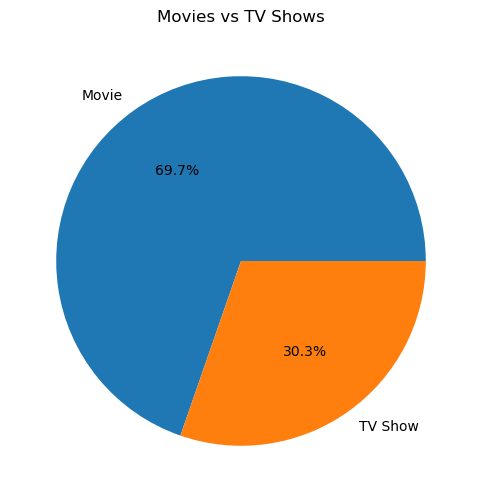

In [13]:
#Movies vs TV Shows Analysis
plt.figure(figsize=(6,6))
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Movies vs TV Shows")
plt.ylabel('')
plt.show()

#Observations
#-Movies are almost 70% part of the Netflix content.
#-TV Shows are relatively a smaller portion of catalog.
#-This shows that Netflix primarily focuses on movie content than Tv Shows.

#Top Genres

In [14]:
top_genres=df['listed_in'].value_counts().head(10)
print("Top Genres are:",top_genres)

Top Genres are: listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


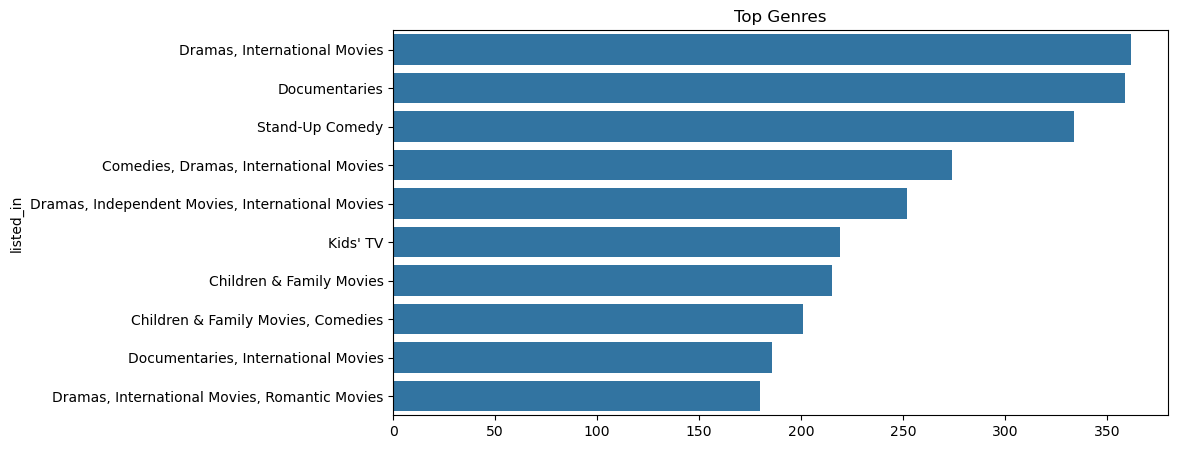

In [22]:
#Genre Analysis
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top Genres")
plt.show()

#Observations
-Dramas,International movies are the most common genres on Netflix.
-Documentries are also highly represented content categories.
-The International Movies genres growth reflects Netflix's global content. 

In [ ]:
#Top Ratings

In [15]:
top_rating=df['rating'].value_counts().head(10)
print("Top Ratings are:",top_rating)

Top Ratings are: rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


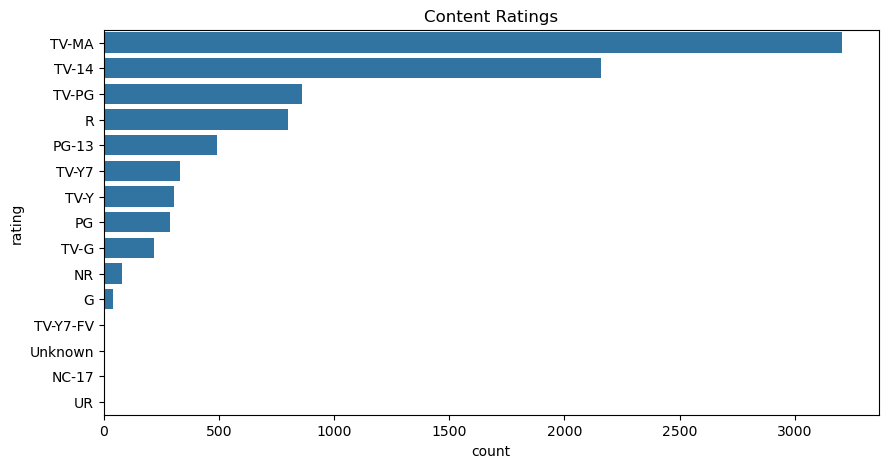

In [17]:
#Ratings Analysis
plt.figure(figsize=(10,5))
sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index
)
plt.title("Content Ratings")
plt.show()

#Observations
-TV-MA is the most common highly used rating category.
-This shows Netflix provides a higher amount of mature-audience content.
-It reflects that major segment of Netflix is formed by adults.

#Content over years

In [18]:
#Earliest release of Netflix
earliest_year=df['release_year'].min()
print("Earliest Release Of Netflix:",earliest_year)

Earliest Release Of Netflix: 1925


In [19]:
#Latest release according to the dataset
latest_release=df['release_year'].max()
print("Latest Release Of Netflix:",latest_release)

Latest Release Of Netflix: 2021


In [20]:
# Year with maximum content
content_per_year=df['release_year'].value_counts()
peak_year=content_per_year.idxmax()
peak_titles=content_per_year.max()
print("Peak year content:",peak_year)
print("Titles Released:",peak_titles)

Peak year content: 2018
Titles Released: 1146


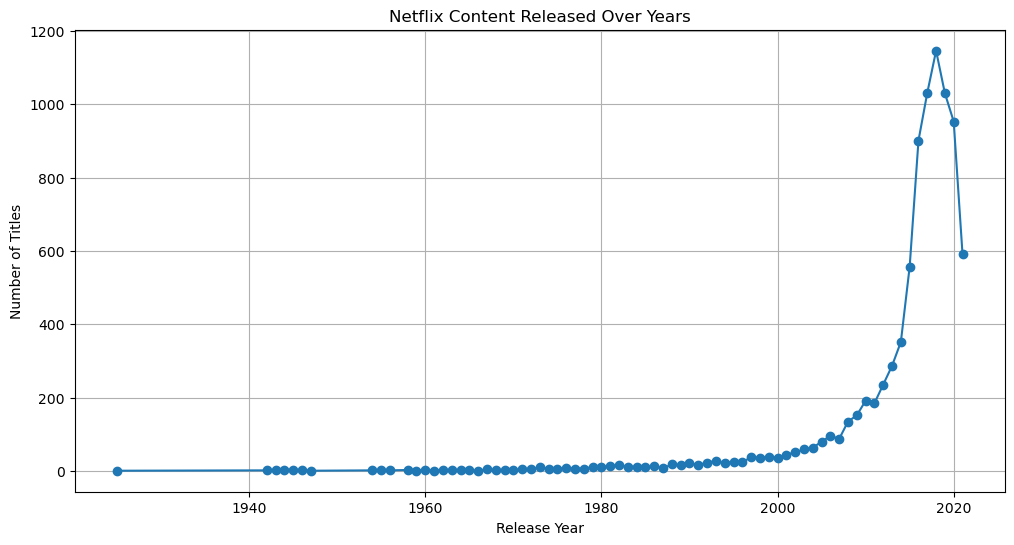

In [21]:
#Content over year Analysis
content_year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(content_year.index,
         content_year.values,
         marker='o')
plt.title('Netflix Content Released Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

#Observation
-Netflix's first content was released in year 1925, but it's production increased after 2015.
-The year 2018 has the highest number of releases.
-Netflix's growth trendingly expanded after 2010.

#Top 10 Actors

In [22]:
actor=df[df['cast']!='Unknown']
actors=actor['cast'].str.split(',').explode()
top_actors=actors.value_counts().head(10)
print("Top actors:",top_actors)

Top actors: cast
 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
Shah Rukh Khan       26
 Rajesh Kava         26
 Andrea Libman       25
 Boman Irani         25
 Paresh Rawal        25
Name: count, dtype: int64


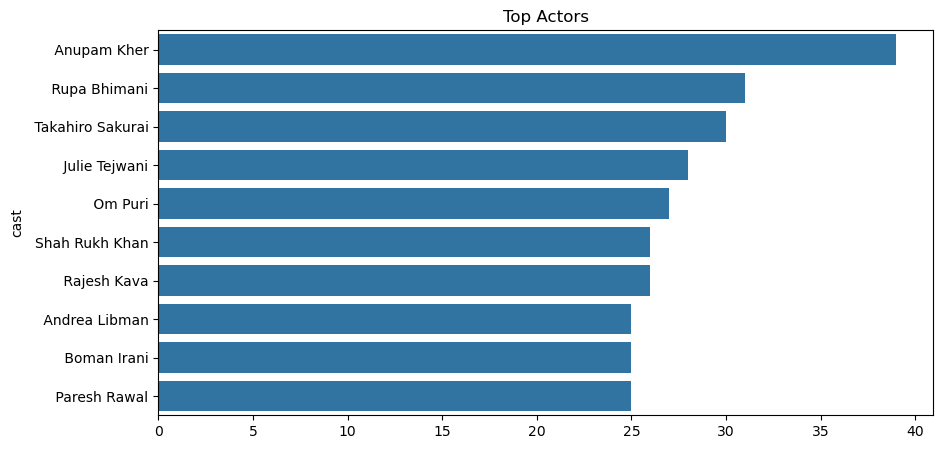

In [33]:
#Top Actors Analysis
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)
plt.title("Top Actors")
plt.show()

#Observations
-This reflects that Anupam Kher ranks as the most frequently appearing actor in the dataset.
-It suggests strong representation of recurring cast members across Netflix's content.
-The cast distribution reflects the Netflix's diverse  and globally sourced content collection.